In [12]:
import time
import math
import random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error

from ncps.torch import CfC

In [13]:
DATA_DIR = Path("data")
WEATHER_PATH = DATA_DIR / "toronto-weather.csv"

In [14]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
print(DEVICE)

cpu


### Visualizing the Data
I love using Pytorch because it makes data visualization much faster and easier.
Here I'll do df.head(len(dataset)) in sudocode and it will allow me to see all the distributions

In [15]:
df = pd.read_csv(WEATHER_PATH)
print(df.shape)
print(df.columns.shape)

df.head(10000)

(402528, 28)
(28,)


,dt,dt_iso,timezone,city_name,lat,lon,temp,visibility,dew_point,feels_like,...,wind_gust,rain_1h,rain_3h,snow_1h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,283996800,1979-01-01 00:00:00 +0000 UTC,21600,Custom location,43.68049,79.38877,-3.92,NaN,-5.42,-6.76,...,NaN,NaN,NaN,NaN,NaN,2,800,Clear,sky is clear,01n
1,284000400,1979-01-01 01:00:00 +0000 UTC,21600,Custom location,43.68049,79.38877,-3.53,NaN,-5.17,-3.53,...,NaN,NaN,NaN,NaN,NaN,9,800,Clear,sky is clear,01n
2,284004000,1979-01-01 02:00:00 +0000 UTC,21600,Custom location,43.68049,79.38877,-4.44,NaN,-5.54,-4.44,...,NaN,NaN,NaN,NaN,NaN,25,802,Clouds,scattered clouds,03n
3,284007600,1979-01-01 03:00:00 +0000 UTC,21600,Custom location,43.68049,79.38877,-0.46,NaN,-5.22,-0.46,...,NaN,NaN,NaN,NaN,NaN,19,801,Clouds,few clouds,02d
4,284011200,1979-01-01 04:00:00 +0000 UTC,21600,Custom location,43.68049,79.38877,0.59,NaN,-5.56,0.59,...,NaN,NaN,NaN,NaN,NaN,20,801,Clouds,few clouds,02d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,319978800,1980-02-21 11:00:00 +0000 UTC,21600,Custom location,43.68049,79.38877,4.62,NaN,-0.33,2.48,...,NaN,NaN,NaN,NaN,NaN,100,804,Clouds,overcast clouds,04d
9996,319982400,1980-02-21 12:00:00 +0000 UTC,21600,Custom location,43.68049,79.38877,3.23,NaN,1.12,0.96,...,NaN,NaN,NaN,NaN,NaN,100,804,Clouds,overcast clouds,04d
9997,319986000,1980-02-21 13:00:00 +0000 UTC,21600,Custom location,43.68049,79.38877,4.57,NaN,1.42,2.13,...,NaN,NaN,NaN,NaN,NaN,100,804,Clouds,overcast clouds,04n
9998,319989600,1980-02-21 14:00:00 +0000 UTC,21600,Custom location,43.68049,79.38877,3.93,NaN,0.45,1.24,...,NaN,NaN,NaN,NaN,NaN,100,804,Clouds,overcast clouds,04n


#### For this quick prototype
Let's just optimize for temperature. In future I might add more than just temperature but for now let's roll with temperature.

In [16]:
TIME_COL = "dt_iso"
TARGET_COL = "temp"

dt_str = df[TIME_COL].str.replace(" UTC", "", regex=False)

df[TIME_COL] = pd.to_datetime(
    dt_str,
    format="%Y-%m-%d %H:%M:%S %z",
    errors="raise",
)

df = df.sort_values(TIME_COL).reset_index(drop=True)

series = df[TARGET_COL].astype(float).to_numpy()

print("Series length:", len(series))
print("First 10 values:", series[:10])
print(df[[TIME_COL, TARGET_COL]].head())

Series length: 402528
First 10 values: [-3.92 -3.53 -4.44 -0.46  0.59  1.49  4.7   5.41  4.93  4.9 ]
                     dt_iso  temp
0 1979-01-01 00:00:00+00:00 -3.92
1 1979-01-01 01:00:00+00:00 -3.53
2 1979-01-01 02:00:00+00:00 -4.44
3 1979-01-01 03:00:00+00:00 -0.46
4 1979-01-01 04:00:00+00:00  0.59


#### Sliding Window

In [17]:
def make_windows(series, seq_len=32, pred_horizon=1):
    X, y = [], []
    for i in range(len(series) - seq_len - pred_horizon + 1):
        X.append(series[i:i + seq_len])
        y.append(series[i + seq_len:i + seq_len + pred_horizon])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    return X, y

SEQ_LEN = 32
PRED_HORIZON = 1

X, y = make_windows(series, seq_len=SEQ_LEN, pred_horizon=PRED_HORIZON)

X = X[..., None]  # (N, seq_len, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (402496, 32, 1)
y shape: (402496, 1)


#### Data Split
Split by time because it's timeseries

In [18]:
split_idx = int(0.8 * len(X))

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(321996, 32, 1) (80500, 32, 1) (321996, 1) (80500, 1)


##### Normalize

In [19]:
x_mean = X_train.mean()
x_std = X_train.std() + 1e-8

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

X_train = (X_train - x_mean) / x_std
X_test = (X_test - x_mean) / x_std

y_train = (y_train - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

##### Dataset Wrapper

In [20]:
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = WeatherDataset(X_train, y_train)
test_ds = WeatherDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([64, 32, 1]) torch.Size([64, 1])


##### Initialize the Models

In [21]:
class TinyTransformerRegressor(nn.Module):
    def __init__(self, input_dim=1, d_model=32, nhead=4, num_layers=1, dim_feedforward=64, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)          # (B, T, d_model)
        x = self.encoder(x)             # (B, T, d_model)
        x = x[:, -1, :]                 # last timestep representation
        out = self.head(x)              # (B, 1)
        return out


class TinyCfCRegressor(nn.Module):
    def __init__(self, input_dim=1, units=32):
        super().__init__()
        self.rnn = CfC(input_dim, units, batch_first=True)
        self.head = nn.Linear(units, 1)

    def forward(self, x):
        y, _ = self.rnn(x)              # y: (B, T, units)
        y = y[:, -1, :]                 # last timestep representation
        out = self.head(y)              # (B, 1)
        return out

In [22]:
transformer_model = TinyTransformerRegressor().to(DEVICE)
cfc_model = TinyCfCRegressor().to(DEVICE)

xb, yb = next(iter(train_loader))
xb = xb.to(DEVICE)

print("Input batch:", xb.shape)
print("Transformer output:", transformer_model(xb).shape)
print("CfC output:", cfc_model(xb).shape)

Input batch: torch.Size([64, 32, 1])
Transformer output: torch.Size([64, 1])
CfC output: torch.Size([64, 1])


In [23]:
def train_one_epoch(model, loader, optimizer, criterion, device="cpu"):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device="cpu"):
    model.eval()
    total_loss = 0.0
    preds_all = []
    targets_all = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        preds = model(xb)
        loss = criterion(preds, yb)

        total_loss += loss.item() * xb.size(0)
        preds_all.append(preds.cpu().numpy())
        targets_all.append(yb.cpu().numpy())

    preds_all = np.concatenate(preds_all, axis=0)
    targets_all = np.concatenate(targets_all, axis=0)

    mse = mean_squared_error(targets_all, preds_all)
    return total_loss / len(loader.dataset), mse, preds_all, targets_all

In [24]:
criterion = nn.MSELoss()

transformer_model = TinyTransformerRegressor().to(DEVICE)
cfc_model = TinyCfCRegressor().to(DEVICE)

transformer_opt = torch.optim.Adam(transformer_model.parameters(), lr=1e-3)
cfc_opt = torch.optim.Adam(cfc_model.parameters(), lr=1e-3)

In [25]:
EPOCHS = 3  # keep it small for the prototype

def run_model(model, optimizer, name):
    print(f"\n=== {name} ===")
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device=DEVICE)
        val_loss, val_mse, preds, targets = evaluate(model, test_loader, criterion, device=DEVICE)
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_mse={val_mse:.4f}")
    return preds, targets

transformer_preds, transformer_targets = run_model(transformer_model, transformer_opt, "TinyTransformer")
cfc_preds, cfc_targets = run_model(cfc_model, cfc_opt, "TinyCfC")


=== TinyTransformer ===
Epoch 1: train_loss=0.0181, val_loss=0.0168, val_mse=0.0168
Epoch 2: train_loss=0.0158, val_loss=0.0165, val_mse=0.0165
Epoch 3: train_loss=0.0157, val_loss=0.0165, val_mse=0.0165

=== TinyCfC ===
Epoch 1: train_loss=0.0097, val_loss=0.0062, val_mse=0.0062
Epoch 2: train_loss=0.0062, val_loss=0.0050, val_mse=0.0050
Epoch 3: train_loss=0.0059, val_loss=0.0055, val_mse=0.0055


In [27]:
def measure_latency(model, loader, device="cpu", n_batches=10):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (xb, _) in enumerate(loader):
            if i >= n_batches:
                break
            xb = xb.to(device)
            start = time.time()
            _ = model(xb)
            end = time.time()
            times.append(end - start)
    return np.mean(times), np.std(times)

t_mean, t_std = measure_latency(transformer_model, test_loader, device=DEVICE)
c_mean, c_std = measure_latency(cfc_model, test_loader, device=DEVICE)

print(f"Transformer latency (s/batch): mean={t_mean:.6f}, std={t_std:.6f}")
print(f"CfC latency (s/batch):        mean={c_mean:.6f}, std={c_std:.6f}")

Transformer latency (s/batch): mean=0.005869, std=0.007250
CfC latency (s/batch):        mean=0.007285, std=0.000538


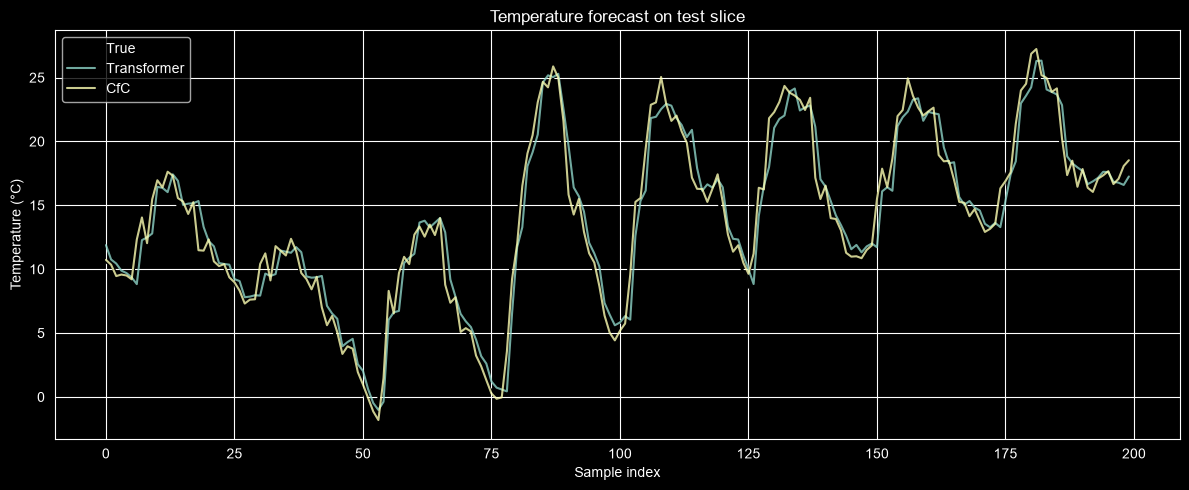

In [26]:
transformer_preds_denorm = transformer_preds * y_std + y_mean
transformer_targets_denorm = transformer_targets * y_std + y_mean

cfc_preds_denorm = cfc_preds * y_std + y_mean
cfc_targets_denorm = cfc_targets * y_std + y_mean

plt.figure(figsize=(12, 5))
slice_len = 200

plt.plot(transformer_targets_denorm[:slice_len], label="True", color="black", linewidth=2)
plt.plot(transformer_preds_denorm[:slice_len], label="Transformer", alpha=0.8)
plt.plot(cfc_preds_denorm[:slice_len], label="CfC", alpha=0.8)

plt.title("Temperature forecast on test slice")
plt.xlabel("Sample index")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()